In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import scipy.constants as spc

In [2]:
res_dressed = "/2024-01-16/2024-01-16T134925_9fda35dc-cw_sparameter" # R.T.: -30dB, vna output: -10dB
res_bare = "/2024-01-16/2024-01-16T135757_d0b62944-cw_sparameter" # R.T.: -30dB, vna output: 20dB
punchout = "/2024-01-16/2024-01-16T135513_6f3516d4-cw_punchout" # R.T.: -30dB, vna output: -20 ~ 20dB

In [3]:
header = "D:/K_sunada/result/CDY154/"
dd_d = datadict_from_hdf5(header + res_dressed +"/data")
dd_b = datadict_from_hdf5(header + res_bare +"/data")


dpr

In [4]:
def S11_dpr_model(freq, fr, ff, kf_e, kf_i, gamma, g, a0, a1, Poff,ed):
    numer = (1j*(freq-ff)+(kf_e-kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    denom = (1j*(freq-ff)-(kf_e+kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*(freq-freq[0])))).conj()
    return model

In [5]:
freq_d = dd_d['frequency']['values']
s11_d = dd_d['s21']['values']
freq_b = dd_b['frequency']['values']
s11_b = dd_b['s21']['values']

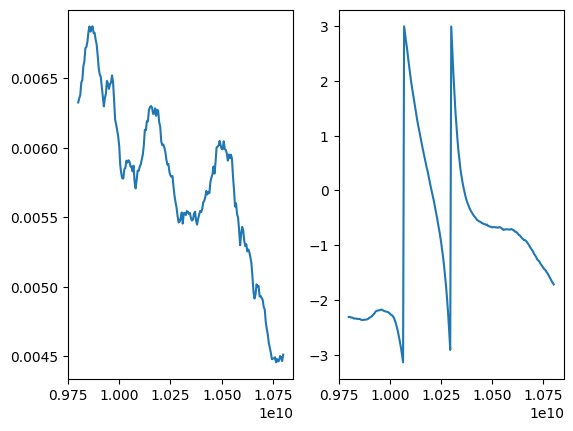

In [6]:
fig,ax = plt.subplots(1,2)
ax[0].plot(freq_d,np.abs(s11_d))
ax[1].plot(freq_d,np.angle(s11_d))

In [7]:
par_ini = {'fr': 10.26e9,  'ff': 10.176e9,    'kf_e': 210e6,   'kf_i': 0.e6,  'g': 82e6, 'gamma': 0.e6,
           'a0': 0.003,  'a1': 0.0,        'Poff': -1,   'ed': -6e-6}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
    
result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')
result_b = model.fit(freq=freq_b, data=s11_b, params=params, method='leastsq')

dressed

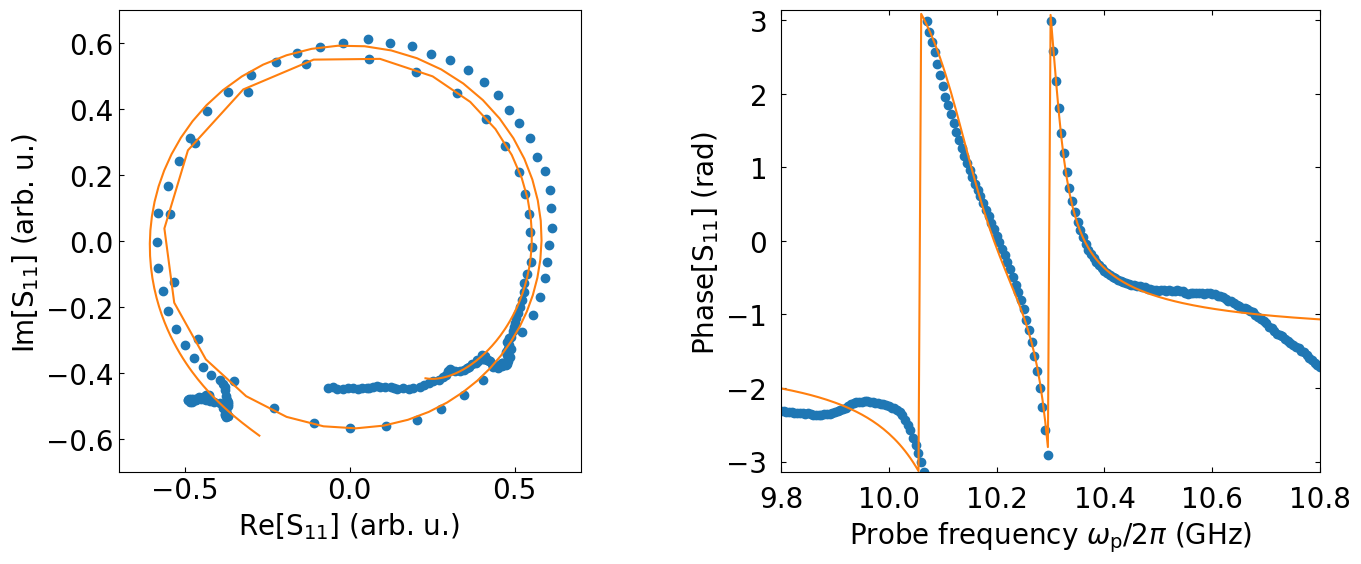

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
# plt.xticks([-0.6, -0.4, 0.2, 0, 0.2, 0.4, 0.6])
ax[0].set_ylim(-0.7, 0.7)
ax[0].set_xlim(-0.7, 0.7)


ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9.8, 10.8)
ax[1].set_ylim(-np.pi, np.pi)
# ax[1].set_aspect("equal", adjustable="box")



ax[0].plot(np.real(s11_d)*1e2,np.imag(s11_d)*1e2, ls='', marker='o')
ax[0].plot(np.real(result_d.best_fit)*1e2,np.imag(result_d.best_fit)*1e2)
# ax[0].plot(np.real(result_d.init_fit),np.imag(result_d.init_fit), color='green', ls='--', )

ax[1].plot(freq_d*1e-9,np.angle(s11_d), ls='', marker='o')
ax[1].plot(freq_d*1e-9,np.angle(result_d.best_fit))
# ax[1].plot(freq_d,np.angle(result_d.init_fit), color='green', ls='--', )

result_d
# plt.savefig('dressed_res.png', bbox_inches='tight')
# plt.show()

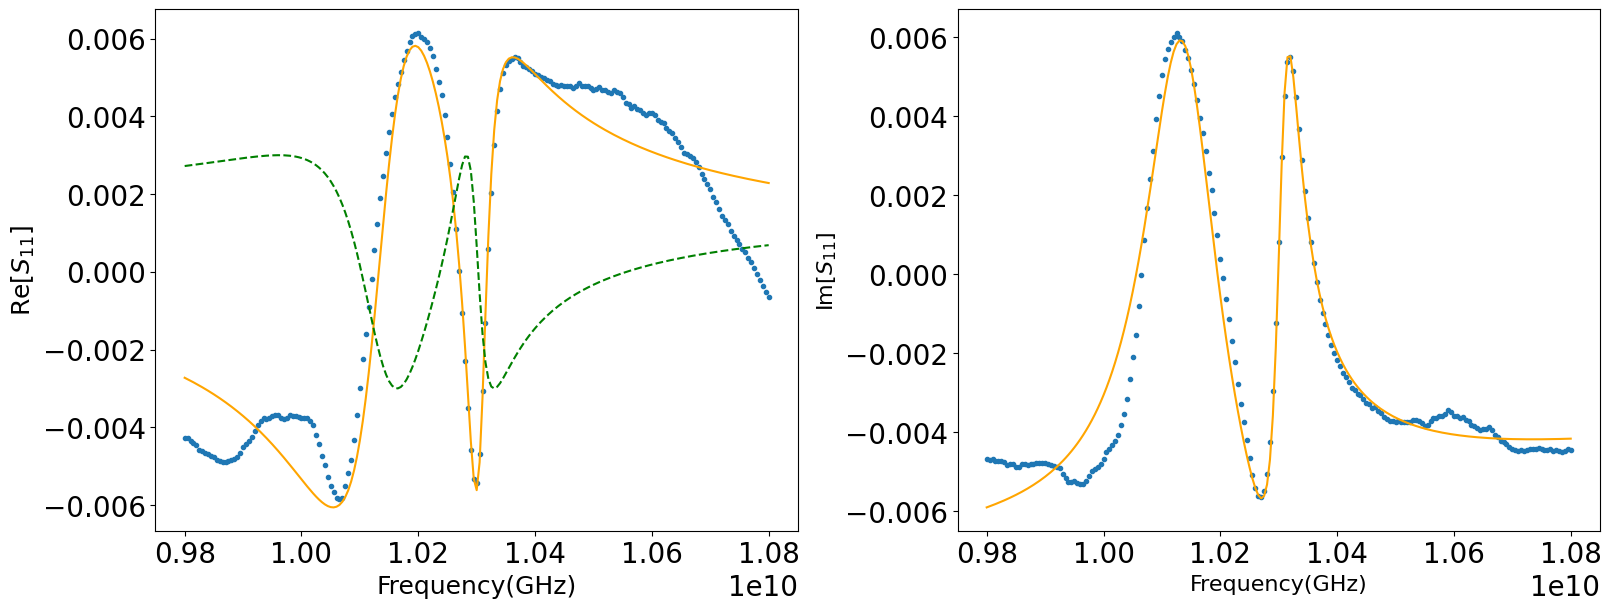

In [9]:
fig, ax = plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
ax[0].set_xlabel('Frequency(GHz)',fontsize=18)
ax[0].set_ylabel('Re[$S_{11}]$', fontsize=18)
ax[1].set_xlabel('Frequency(GHz)',fontsize=16)
ax[1].set_ylabel('Im[$S_{11}]$', fontsize=16)
# ax.tick_params(direction='in')

ax[0].plot(freq_d,np.real(s11_d), ls='', marker='.')
ax[0].plot(freq_d,np.real(result_d.best_fit), color='orange')
ax[0].plot(freq_d,np.real(result_d.init_fit), color='green', ls='--', marker='')
ax[1].plot(freq_d,np.imag(s11_d), ls='', marker='.')
ax[1].plot(freq_d,np.imag(result_d.best_fit), color='orange')


bare

In [10]:
par_ini = {'fr': 10.255e9,  'ff': 10.176e9,    'kf_e': 248e6,   'kf_i': 0.e6,  'g': 86e6, 'gamma': 0.e6,
           'a0': 0.0037,  'a1': 0.0,        'Poff': -0.47,   'ed': -7e-6}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
    
result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')
result_b = model.fit(freq=freq_b, data=s11_b, params=params, method='leastsq')

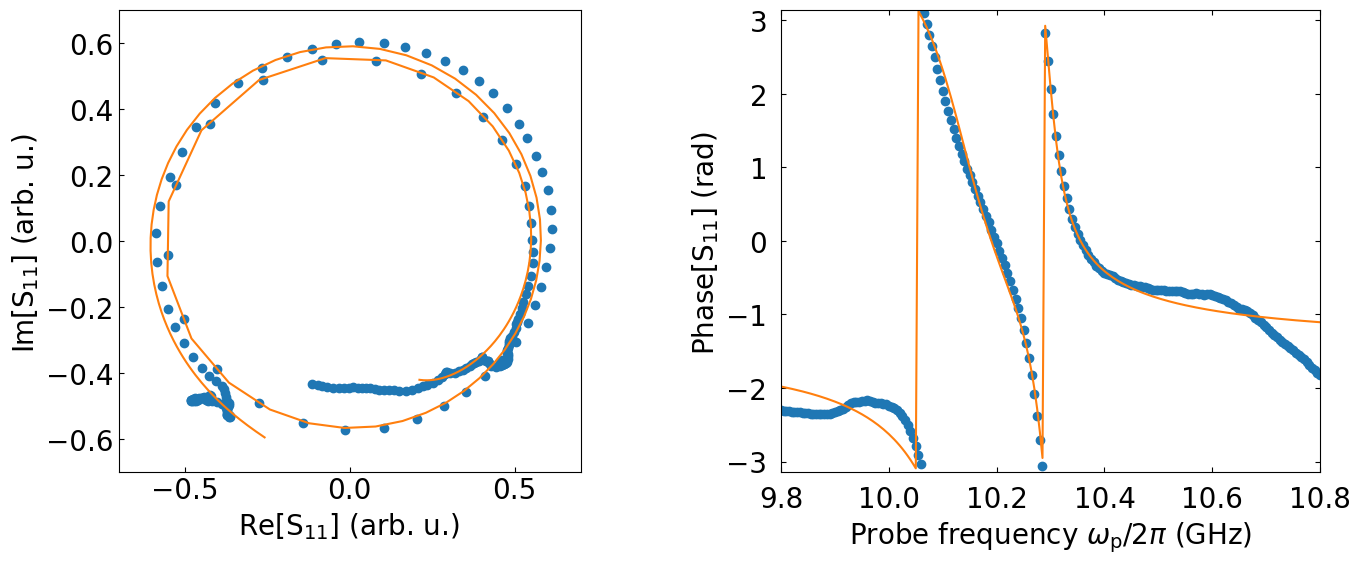

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_ylim(-0.7, 0.7)
ax[0].set_xlim(-0.7, 0.7)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9.8, 10.8)
ax[1].set_ylim(-np.pi, np.pi)


ax[0].plot(np.real(s11_b)*1e2,np.imag(s11_b)*1e2, ls='', marker='o')
ax[0].plot(np.real(result_b.best_fit)*1e2,np.imag(result_b.best_fit)*1e2)
# ax[0].plot(np.real(result_d.init_fit),np.imag(result_d.init_fit), color='green', ls='--', )

ax[1].plot(freq_b*1e-9,np.angle(s11_b), ls='', marker='o')
ax[1].plot(freq_b*1e-9,np.angle(result_b.best_fit))
# ax[1].plot(freq_d,np.angle(result_d.init_fit), color='green', ls='--', )

result_b
# plt.savefig('bare_res.png', bbox_inches='tight')

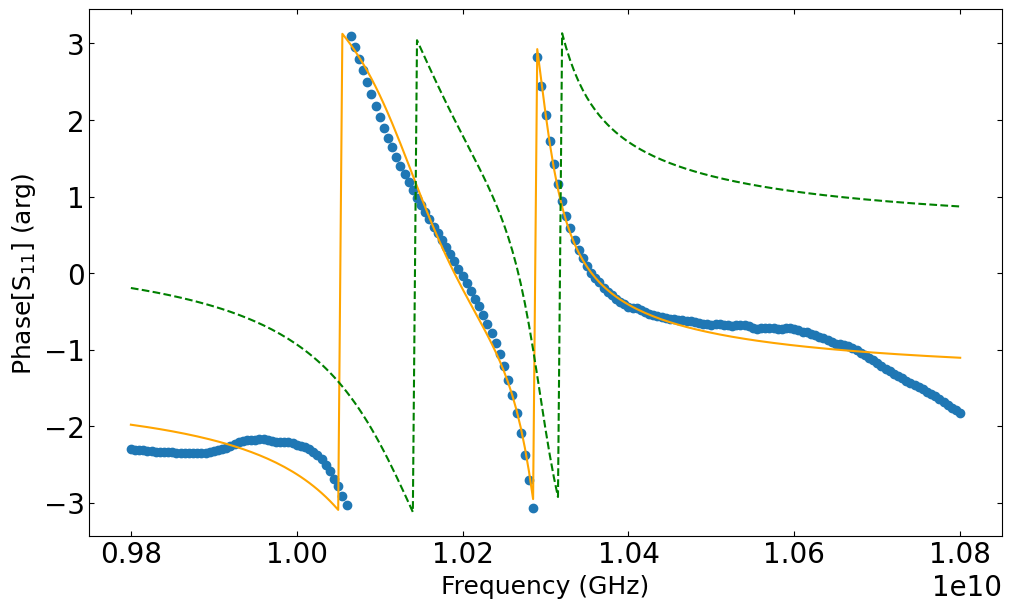

In [12]:
fig, ax = plt.subplots(figsize=(10,6),constrained_layout=True)
plt.rcParams["font.size"] = 15
ax.set_xlabel('Frequency (GHz)',fontsize=18)
ax.set_ylabel('Phase[S$_{11}$] (arg) ', fontsize=18)
# ax.tick_params(direction='in')
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)

plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

ax.plot(freq_b,np.angle(s11_b), ls='', marker='o')

ax.plot(freq_b,np.angle(result_b.best_fit), color='orange')
ax.plot(freq_b,np.angle(result_b.init_fit), color='green', ls='--', )

# ax[1][0].plot(freq,np.abs(s11) - np.abs(result.best_fit), ls='', marker='.')
# error_phi = np.angle(s11) - np.angle(result.best_fit)
# error_phi[error_phi>np.pi] -= 2*np.pi
# error_phi[error_phi<-np.pi] += 2*np.pi
# ax[1][1].plot(freq,error_phi, ls='', marker='.')

result_b

punchout

In [13]:
dd = datadict_from_hdf5(header + punchout +"/data")
dd

s11: (15, 1001)
  ⌙ frequency (Hz): (15, 1001)
  ⌙ power (dBm): (15,)

In [14]:
dd = datadict_from_hdf5(header + punchout +"/data")
x = np.unique(dd['power']['values'])
y = np.unique(dd['frequency']['values'])
z = dd['s11']['values']

C:\Users\qipe\AppData\Local\Temp\ipykernel_16700\3573284690.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


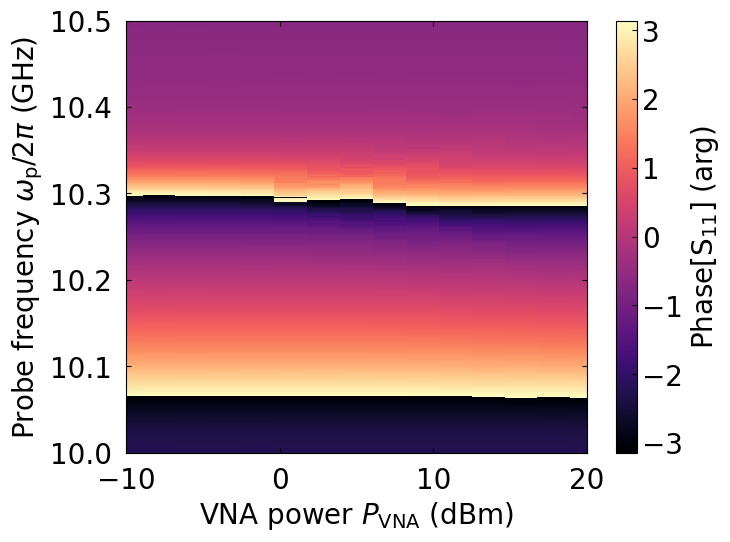

In [37]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("VNA power $P_{\mathrm{VNA}}$ (dBm)")
ax.set_ylabel("Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)")
ax.set_xlim(-10, 20)
ax.set_ylim(10, 10.5)

maingraph = ax.pcolormesh(x,y*1e-9, np.angle(z).reshape(15, 1001).T, vmin=min(np.unique(np.angle(z))), vmax=max(np.unique(np.angle(z))), cmap=cm, shading='auto')


plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on')
# plt.savefig('punchout.png', bbox_inches='tight')
plt.show()


平均光子数

In [16]:
def ave_photon_number(Power, k_ex, k_in, omega_r, omega_p):
    n = (k_ex/(((k_in + k_ex)/2)**2 + (omega_r - omega_p)**2))*(Power/(spc.hbar * omega_p))
    return n

In [17]:
spc.hbar

1.0545718176461565e-34

In [18]:
k_ex = 2.0003e8*(2*np.pi)
k_in = 0

omega_r = 1.0267e+10*2*np.pi
omega_p = 1.0177e+10*2*np.pi

Power =  10**((-22.4-10-2.3-50-20)/10) *1e-3#J/s
Power
# ave_photon_number(Power, k_ex, k_in, omega_r, omega_p)


3.3884415613920344e-14

In [19]:
P =  (10**((-50)/10) *1e-3  /6.626e-34 )*1e-9#GHz/s
P


1.509206157561123e+16

In [20]:
kai = (0.13e9)*2*np.pi/2
delta = (10.2503210-8.02-0.00233)*1e9*2*np.pi
g = (kai*delta)**0.5
g

2391075352.76259

In [21]:
delta**2/(4*g**2)

8.569196153846155

In [22]:
k_ex

1256825556.9951327

In [23]:
Power, omega_p, omega_r, k_ex, k_in

(3.3884415613920344e-14,
 63943976871.16665,
 64509463548.81281,
 1256825556.9951327,
 0)

In [24]:
1/(10.209-10.066)

6.993006993007047

# frequency optimization

In [91]:
header = "D:/K_sunada/result/CDY154/"
data = "/2024-01-16/2024-01-16T183015_dabc7948-26_freq_optimize"
dd = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

x = dd['frequency']['values']
s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_e = dd['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq))


eg-peak

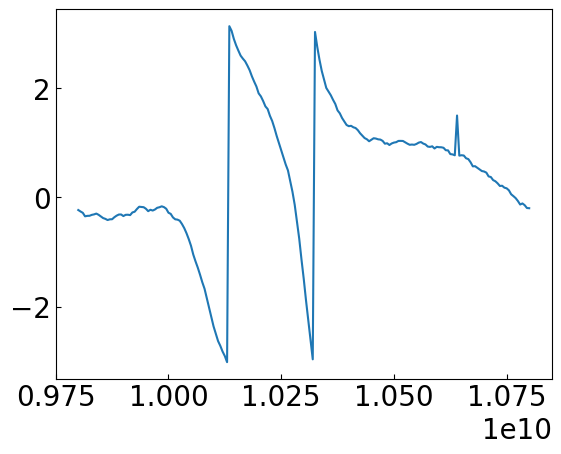

In [92]:
plt.plot(freq, np.angle(s11_g))
plt.show()

In [93]:
def Lorentzian(freq, amp, const, center, k):
    return const + amp*k**2/((freq-center)**2 + k**2)

In [94]:
import sklearn
from sklearn.decomposition import PCA

In [95]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

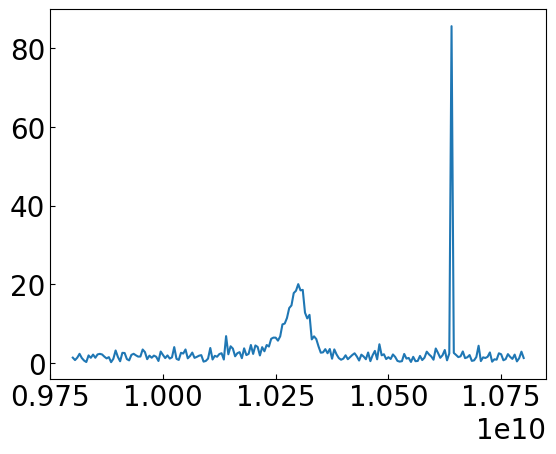

In [96]:
I = s11_eg.real
Q = s11_eg.imag
plt.plot(freq, np.abs(s11_eg))
PCAge = PCA_transform(I, Q)

In [97]:
par_ini = {
    'amp': 20,
    'const':1,
    'center':10.27e9,
    'k':0.008e9
}

par_min = {
    'amp': 0,
    'const':0,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [98]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [99]:
result = model.fit(data = np.abs(s11_eg), params = params, freq = x)
result

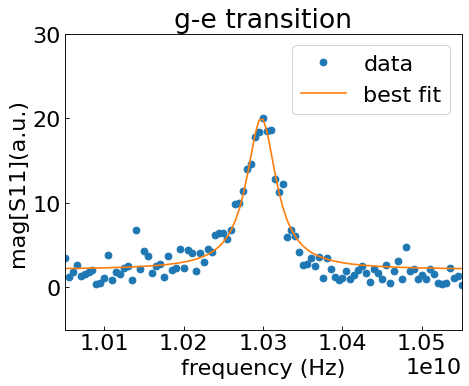

In [100]:
fig, ax = plt.subplots(dpi=80)

plt.title("g-e transition")


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.xlim(10.05e9, 10.55e9)
plt.ylim(-5, 30)

plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

omega_g, _e fitting

In [101]:
par_ini = {'fr': 10.267e9,  'ff': 10.177e9,    'kf_e': 200e6,   'kf_i': 0,  'g': 83e6, 'gamma': 0,
           'a0': 50,  'a1': 0,        'Poff': 1.5,   'ed': 0}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': 0,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': False,    'kf_i':False,    'g': False, 'gamma': False,
           'a0': True, 'a1': False,    'Poff': True,  'ed': False}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

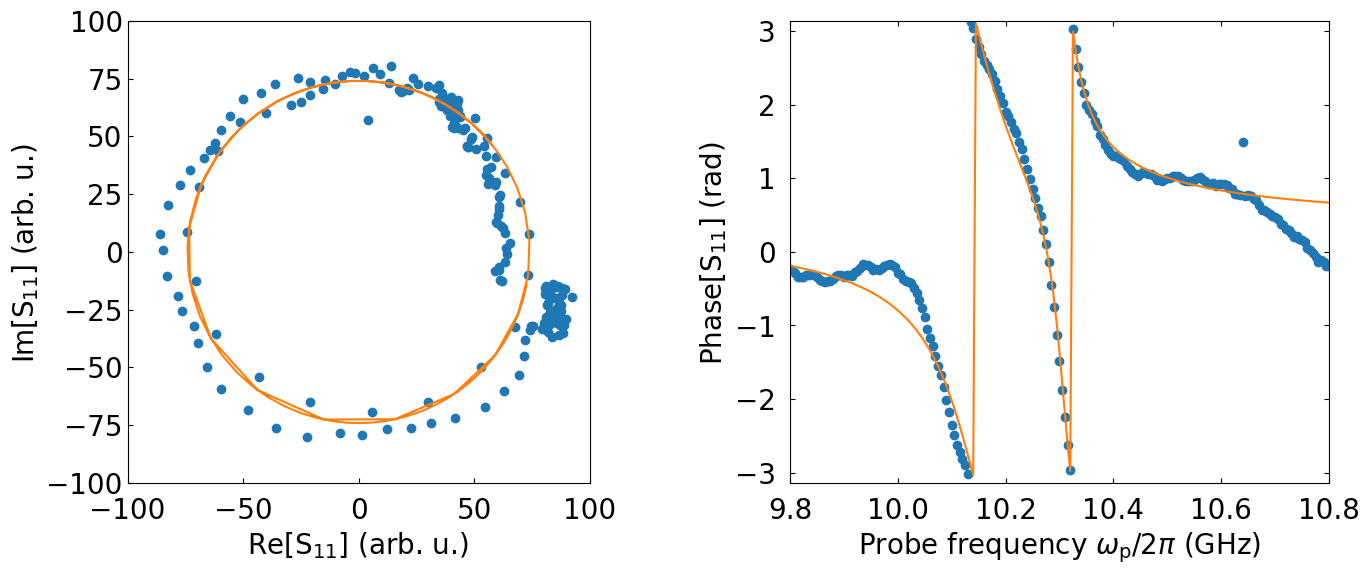

In [114]:
res = model.fit(data = s11_g, params = params, freq = x)

fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_xlim(-100, 100)
ax[0].set_ylim(-100, 100)
ax[0].get_xaxis().set_tick_params(pad=10)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9.8, 10.8)
ax[1].set_ylim(-np.pi, np.pi)


ax[0].plot(np.real(s11_g),np.imag(s11_g) , ls='', marker='o')
# ax[0].plot(x, np.real(res.init_fit), '--', label='initial fit', color='orange')
ax[0].plot(np.real(res.best_fit), np.imag(res.best_fit))
ax[1].plot(x*1e-9, np.angle(s11_g),  ls='', marker='o')
# ax[1].plot(x, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(x*1e-9, np.angle(res.best_fit))
# plt.savefig('chi_g.png', bbox_inches='tight')
plt.show()
res

In [116]:
par_ini = {'fr': 10.27e9,  'ff': 10.183e9,    'kf_e': 200e6,   'kf_i': 0,  'g': 83e6, 'gamma': 0,
           'a0': 50,  'a1': 0,        'Poff': 1.5,   'ed': 0}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': 0,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': False,    'kf_i':False,    'g': False, 'gamma': False,
           'a0': True, 'a1': False,    'Poff': True,  'ed': False}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

In [1]:
res = model.fit(data = s11_e, params = params, freq = x, method='nelder')

fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_xlim(-100, 100)
ax[0].set_ylim(-100, 100)
ax[0].get_xaxis().set_tick_params(pad=10)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9.8, 10.8)
ax[1].set_ylim(-np.pi, np.pi)

ax[0].plot(np.real(s11_e), np.imag(s11_e),  ls='', marker='o')
# ax[0].plot(x, np.real(s11_e),'.', color='k')
# ax[0].plot(np.real(res.init_fit), np.imag(res.init_fit),'--', label='initial fit', color='orange')
# ax[0].plot(np.real(res.best_fit),np.imag(res.best_fit), '-', label='best fit', color='red')
ax[0].plot(np.real(res.best_fit), np.imag(res.best_fit))
ax[1].plot(x*1e-9, np.angle(s11_e),  ls='', marker='o')
# ax[1].plot(x*1e-9, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(x*1e-9, np.angle(res.best_fit))
# plt.savefig('chi_e.png', bbox_inches='tight')
plt.show()
res

NameError: name 'model' is not defined

In [ ]:
f_hg = 10.266e9
f_lg = 10.183e9
f_he = 10.263e9
f_le = 10.183e9

# chi_l = (f_le - f_lg)/2
chi_h = (f_he - f_hg)/2
chi = chi_h
chi

-1500000.0